# **PISA STUDENTS**

## Imports

In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score
from data import category_split, balance_feature, frame_status_info
from evaluation import evaluate_model, plot_model_acc_and_fscore, display_model_weights, evaluate_model_thresholded_regression, evaluate_model_classifier

Using device: cpu


## Settings

In [2]:
DATA_RELATIVE_PATH = "data/pisa_2022/p22_stu_filtered.csv"

TARGET_COLUMN = "GENERAL_SCORE"
TARGET_OPERTOR = "<" #Does not change the training, only splits
TARGET_VALUE = 400 #This value will be changed in a future cell
PERCENTILE = 10


RANDOM_SEED = 42
SPLIT_PERCENTAGE_TESTING = 0.30

BALANCE_DATA = True
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE) #This value is updated in future cell
BALANCE_QUERY_NON_TARGET_PERCENTAGE = 0.50


REGULARIZER_WEIGTH = 0.01
#MODEL_THERESHOLD_REG = TARGET_VALUE
MODEL_THERESHOLD_LOG = 0.5

DEBUG_MODE = True


## Loading the Data

In [3]:
# Load dataset
data_file = os.path.join(os.getcwd(), DATA_RELATIVE_PATH)
df = pd.read_csv(data_file)
print("Loaded datafile")
print(df.shape)

Loaded datafile
(6072, 508)


# Data processing

### Irrelevant data

In [4]:
#Remove constant columns
df = df.loc[:, df.nunique() > 1]

### Identical Data

In [5]:
# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")

Removed duplicate rows


### Missing data

In [6]:
# Investigation
# Count missing values per column
missing_counts = df.isnull().sum()

# Total number of rows
total_rows = len(df)

# Create summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': (missing_counts / total_rows * 100).round(2)
})

# Filter to only show columns with missing data
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Sort by most missing values
missing_summary = missing_summary.sort_values(by='Missing Percent', ascending=False)

# Display result
print(missing_summary.head(120))  # Show top 20, adjust as needed

            Missing Count  Missing Percent
ST354Q04JA           4420            72.79
ST354Q08JA           4415            72.71
ST354Q01JA           4409            72.61
ST354Q09JA           4398            72.43
ST354Q03JA           4394            72.36
...                   ...              ...
ST293Q05JA           3166            52.14
ST283Q06JA           3156            51.98
ST293Q03JA           3153            51.93
ST275Q02WA           3148            51.84
ST290Q05WA           3138            51.68

[120 rows x 2 columns]


In [7]:
# All data is present in this dataframe.
# Fill NaN values in numeric columns with the column mean
df = df.apply(lambda col: col.fillna(col.mean()) if pd.api.types.is_numeric_dtype(col) else col)

### Data transformation

In [8]:
# Round all float columns to 2 decimal places
df = df.apply(lambda col: col.round(2) if pd.api.types.is_float_dtype(col) else col)

### POST REMOVAL

In [9]:
print(df.shape)

(6072, 508)


## Feature Processing

### Columns to be removed

In [10]:
#Remove columns
columns_to_remove = ["CNTSTUID", "ST004D01T", "AGE", "SCIENCE_AVG", "MATH_AVG", "READING_AVG", "ST251D08JA", "OCOD1", "OCOD2", "OCOD3", "PROGN", "ISCEDP", "COBN_S", "COBN_M", "COBN_F", "LANGN"]
df.drop(columns=columns_to_remove, inplace=True, errors='ignore')

### Prediction column analysis

In [11]:
# Calculate the score corresponding to that percentile
THRESHOLD_SCORE = df['GENERAL_SCORE'].quantile(PERCENTILE / 100)

print(f"{PERCENTILE}th percentile score: {THRESHOLD_SCORE:.2f}")

# Optionally: Filter students at or below that percentile
lowest_students = df[df['GENERAL_SCORE'] <= THRESHOLD_SCORE]

print(f"Number of students at or below the {PERCENTILE}th percentile: {len(lowest_students)}")
print(lowest_students[['GENERAL_SCORE']].head())

TARGET_VALUE = THRESHOLD_SCORE
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE)

10th percentile score: 357.31
Number of students at or below the 10th percentile: 608
    GENERAL_SCORE
25         351.27
41         324.81
44         356.80
46         341.33
60         325.31


## Splitting data

### Split

In [12]:
train_df, test_df = train_test_split(df, test_size=SPLIT_PERCENTAGE_TESTING, random_state=RANDOM_SEED)
frame_status_info(train_df, test_df)

Training data shape: (4250, 492)
Testing data shape: (1822, 492)


### Balance

In [13]:
if (BALANCE_DATA):
    match_df, no_match_df = category_split(train_df, BALANCE_QUERY)
    train_balanced = balance_feature(match_df, no_match_df, BALANCE_QUERY_NON_TARGET_PERCENTAGE)

## Training

### Preparation

In [14]:
# Define features and target variable
temp_train : pd.DataFrame = train_balanced if BALANCE_DATA else train_df

frame_status_info(temp_train, test_df)
print("Training percentage:", test_df.shape[0]/(temp_train.shape[0]+test_df.shape[0]))

X_train = temp_train.drop(columns=[TARGET_COLUMN]).values
y_train_reg = temp_train[TARGET_COLUMN]
y_train_cls = (temp_train[TARGET_COLUMN] < TARGET_VALUE).astype(int)

X_test = test_df.drop(columns=[TARGET_COLUMN]).values
y_test_reg = test_df[TARGET_COLUMN]
y_test_cls = (test_df[TARGET_COLUMN] < TARGET_VALUE).astype(int)

Training data shape: (414, 492)
Testing data shape: (1822, 492)
Training percentage: 0.8148479427549195


### Execution

In [15]:
# Train regression models
print("Training RegN")
model_reg_no = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model_reg_l1 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Reg2")
model_reg_l2 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

# Train logistic models
print("Training LogN")
model_log_no = train_logistic_model(X_train, y_train_cls.values, reg_type=None)  # Standard
print("Training Log1")
model_log_l1 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Log2")
model_log_l2 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

Training RegN
Training Reg1


c:\Users\jonat\anaconda3\envs\student_performance_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training Reg2


c:\Users\jonat\anaconda3\envs\student_performance_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training LogN
Training Log1
Training Log2


## Evaluation

### Execution

Regression Models:
[Standard Linear Regression] Sample predicted scores: [3.91231610e+14 3.82419913e+14 3.04634508e+14 2.49004830e+14
 3.84008970e+14 1.52130425e+14 3.23992740e+14 3.30717919e+14
 4.65892932e+14 1.73473653e+14]
[Standard Linear Regression] Applied threshold: 357.314
[Standard Linear Regression] Predicted labels: [False False False False False False False False False False]
[Standard Linear Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Standard Linear Regression] Accuracy: 0.889681668496158
[Standard Linear Regression] F1 Score: 0.056338028169014086


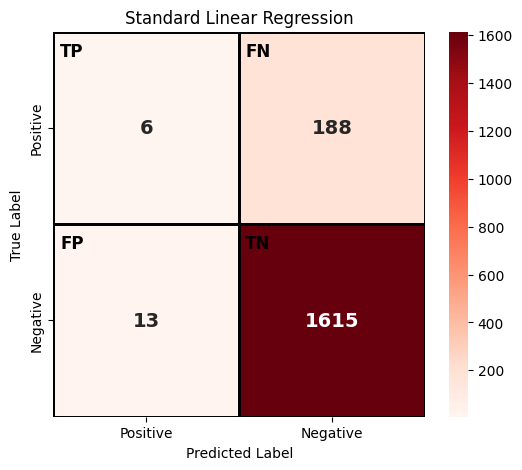

[Lasso Regression] Sample predicted scores: [-6.90744874e+13 -7.51642687e+13 -6.53317935e+13 -9.15114112e+13
 -8.68593125e+13 -6.84011947e+13 -4.76983911e+13 -6.61955173e+13
 -8.14897787e+13 -5.24354031e+13]
[Lasso Regression] Applied threshold: 357.314
[Lasso Regression] Predicted labels: [ True  True  True  True  True  True  True  True  True  True]
[Lasso Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Lasso Regression] Accuracy: 0.10592755214050494
[Lasso Regression] F1 Score: 0.19156327543424315


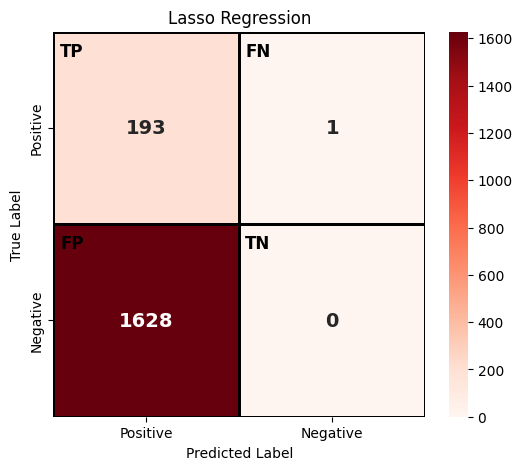

[Ridge Regression] Sample predicted scores: [1.27489096e+10 1.21525106e+10 4.25846042e+09 7.58850259e+09
 1.19720906e+10 9.73665667e+09 9.49563776e+09 9.46742272e+09
 1.13132439e+10 8.19448905e+09]
[Ridge Regression] Applied threshold: 357.314
[Ridge Regression] Predicted labels: [False False False False False False False False False False]
[Ridge Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Ridge Regression] Accuracy: 0.8924259055982436
[Ridge Regression] F1 Score: 0


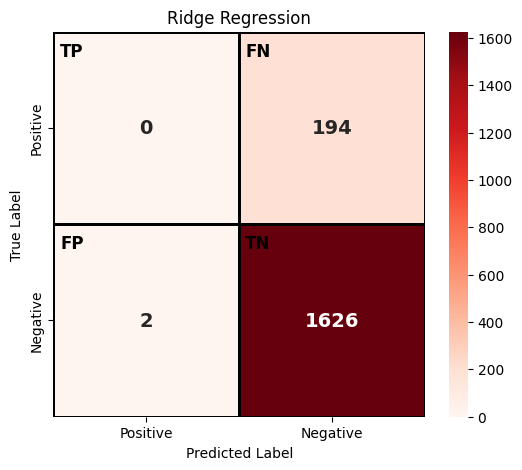

Logistic Models:
[Standard Logistic Regression] Sample predicted probabilities: [1.00000000e+000 1.00000000e+000 0.00000000e+000 1.00000000e+000
 1.00000000e+000 5.16011166e-156 0.00000000e+000 1.00000000e+000
 1.00000000e+000 1.00000000e+000]
[Standard Logistic Regression] Applied threshold: 0.5
[Standard Logistic Regression] Predicted labels: [ True  True False  True  True False False  True  True  True]
[Standard Logistic Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Standard Logistic Regression] Accuracy: 0.24972557628979145
[Standard Logistic Regression] F1 Score: 0.18485390578413832


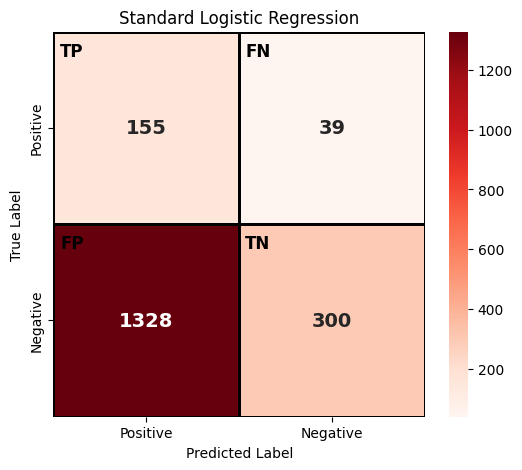

[Lasso Logistic Regression] Sample predicted probabilities: [5.06163824e-118 2.44555822e-091 1.08970681e-207 4.77186964e-134
 7.00873417e-099 4.62639621e-188 3.19156753e-151 1.51211809e-102
 1.38373823e-088 3.68129084e-134]
[Lasso Logistic Regression] Applied threshold: 0.5
[Lasso Logistic Regression] Predicted labels: [False False False False False False False False False False]
[Lasso Logistic Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Lasso Logistic Regression] Accuracy: 0.893523600439078
[Lasso Logistic Regression] F1 Score: 0


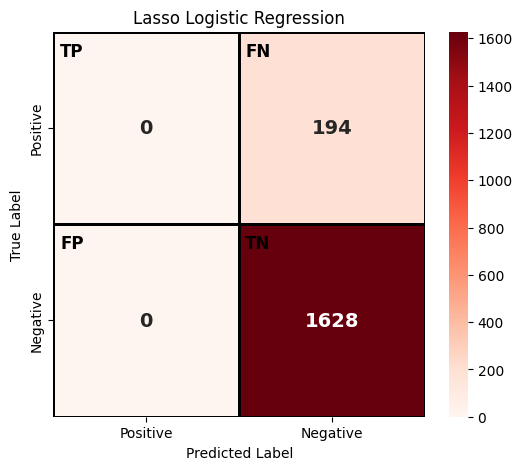

[Ridge Logistic Regression] Sample predicted probabilities: [9.99987037e-01 1.00000000e+00 2.48184243e-05 9.99999839e-01
 1.00000000e+00 4.07161028e-01 9.98503929e-01 1.00000000e+00
 1.00000000e+00 9.99924305e-01]
[Ridge Logistic Regression] Applied threshold: 0.5
[Ridge Logistic Regression] Predicted labels: [ True  True False  True  True False  True  True  True  True]
[Ridge Logistic Regression] Sample true values: [1 0 0 0 0 0 1 0 0 1]
[Ridge Logistic Regression] Accuracy: 0.23929747530186607
[Ridge Logistic Regression] F1 Score: 0.1894736842105263


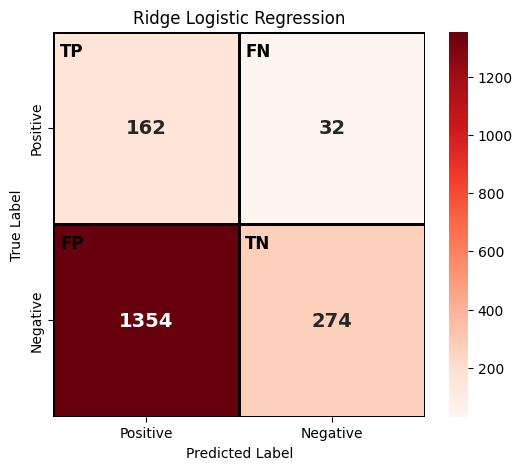

In [16]:
# Evaluate regression models
print("Regression Models:")
acc_reg_no, f_reg_no = evaluate_model_thresholded_regression(model_reg_no, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Standard Linear Regression", debug=DEBUG_MODE)
acc_reg_l1, f_reg_l1 = evaluate_model_thresholded_regression(model_reg_l1, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Lasso Regression", debug=DEBUG_MODE)
acc_reg_l2, f_reg_l2 = evaluate_model_thresholded_regression(model_reg_l2, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Ridge Regression", debug=DEBUG_MODE)

# Evaluate logistic models
print("Logistic Models:")
acc_log_no, f_log_no = evaluate_model_classifier(model_log_no, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Standard Logistic Regression", debug=DEBUG_MODE)
acc_log_l1, f_log_l1 = evaluate_model_classifier(model_log_l1, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Lasso Logistic Regression", debug=DEBUG_MODE)
acc_log_l2, f_log_l2 = evaluate_model_classifier(model_log_l2, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Ridge Logistic Regression", debug=DEBUG_MODE)

### Analysis

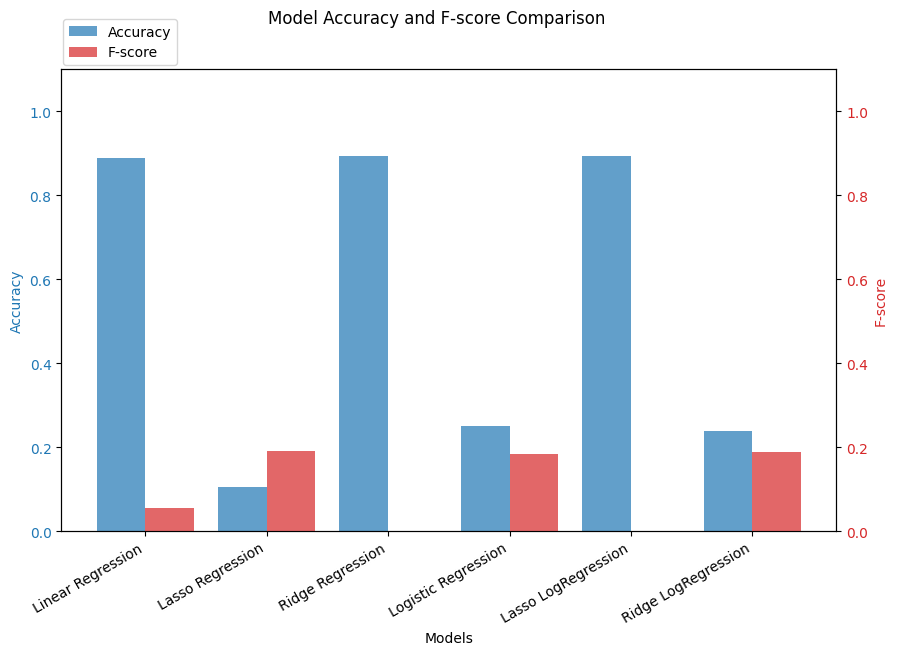

In [17]:
accs = [acc_reg_no, acc_reg_l1, acc_reg_l2, acc_log_no, acc_log_l1, acc_log_l2]
fscores = [f_reg_no, f_reg_l1, f_reg_l2, f_log_no, f_log_l1, f_log_l2]
model_names = ["Linear Regression", "Lasso Regression", "Ridge Regression",
               "Logistic Regression", "Lasso LogRegression", "Ridge LogRegression"]
plot_model_acc_and_fscore(accs, fscores, model_names)

### Weights

In [18]:
display_model_weights(model_reg_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

        Feature  Absolute value weight        Weight
399  IC180Q05JA           2.557729e+12 -2.557729e+12
268  ST348Q02JA           2.524386e+12  2.524386e+12
147  ST283Q09JA           2.469818e+12  2.469818e+12
429    SKIPPING           2.344463e+12  2.344463e+12
379  IC177Q05JA           2.273295e+12 -2.273295e+12
231  ST300Q04JA           2.235796e+12 -2.235796e+12
192  ST291Q08JA           2.221333e+12  2.221333e+12
7    ST251Q03JA           2.126919e+12  2.126919e+12
423  IC183Q16JA           2.088713e+12 -2.088713e+12
126  ST270Q01JA           2.077148e+12 -2.077148e+12
Displayed sorted feature weights


In [19]:
display_model_weights(model_log_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

        Feature  Absolute value weight     Weight
196  ST289Q02JA              12.453617 -12.453617
74   ST038Q10JA              10.633387  10.633387
126  ST270Q01JA               8.882612  -8.882612
224  ST297Q05JA               8.535495   8.535495
72   ST038Q08NA               8.054081  -8.054081
56   ST267Q04JA               7.535267  -7.535267
107  ST263Q02JA               7.351205  -7.351205
477    ICTAVSCH               7.156599  -7.156599
479    ICTAVHOM               7.126370  -7.126370
287  ST352Q03JA               6.641114  -6.641114
Displayed sorted feature weights
